## MODEL PREPROCESSING

In [ ]:
!apt-get install ffmpeg

!ffmpeg -codecs | grep 729

**CONVERTING .G729A AND PCM to .WAV**

**Directly to GDrive**

In [ ]:
import subprocess
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

# 1. Decoder Function
def decode_audio_robust(in_path, out_path, target_sr=44100, min_duration=0.5):
    """
    Robustly decodes audio using ffmpeg with validation checks.
    Handles .pcm (raw s16le 8k) and .g729a specifically.
    """

    # --- A. Construct FFmpeg Command based on extension ---
    cmd = ["ffmpeg", "-y"]

    # Specific handling for dataset's raw PCM files
    if in_path.endswith(".pcm"):
        # Original script logic: raw s16le, 8000Hz, mono
        cmd.extend(["-f", "s16le", "-ar", "8000", "-ac", "1"])
    elif in_path.endswith(".g729a"):
        # Original script logic: g729 format
        cmd.extend(["-f", "g729"])

    # Standard output settings (resample to target_sr)
    cmd.extend(["-i", in_path, "-ar", str(target_sr), "-ac", "1", out_path])

    # --- B. Run FFmpeg  ---
    try:
        result = subprocess.run(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )

        # Check return code
        if result.returncode != 0:
            return False, f"ffmpeg_error: {result.stderr[:200]}", 0, 0

    except Exception as e:
        return False, f"subprocess_crash: {str(e)}", 0, 0

    # --- C. Validate the Output  ---
    if not os.path.exists(out_path):
        return False, "missing_output_file", 0, 0

    try:
        # Load with librosa to verify integrity, SR, and content
        y, sr = librosa.load(out_path, sr=None, mono=True)
    except Exception as e:
        return False, f"librosa_load_fail: {str(e)}", 0, 0

    # 1. Check Sample Rate
    if sr != target_sr:
        return False, f"sr_mismatch_got_{sr}", 0, 0

    # 2. Check Duration
    duration = len(y) / sr
    if duration < min_duration:
        return False, f"too_short_{duration:.2f}s", duration, sr

    # 3. Check Energy / Validity
    if not np.isfinite(y).all():
        return False, "contains_nan_or_inf", duration, sr

    if np.mean(y**2) < 1e-8:
        return False, "silent_empty_audio", duration, sr

    return True, "ok", duration, sr


**Standardize audio**

In [ ]:
import librosa
import soundfile as sf
import numpy as np
import os

def standardize_audio_robust(input_path, output_dir, target_sr=44100):
    """
    Forensic-grade standardization:
    1. Loads audio (preserving native SR first to check).
    2. Resamples ONLY if necessary (preventing hard failures).
    3. Sanitizes signal (NaN removal, Clipping).
    4. Saves the clean version for feature extraction.
    """
    fname = os.path.basename(input_path)
    out_path = os.path.join(output_dir, fname)

    try:
        # 1. Load Audio
        y, sr = librosa.load(input_path, sr=None, mono=True)

        # 2. Resample if mismatch
        if sr != target_sr:
            y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
            sr = target_sr

        # 3. Safety: Handle NaNs
        if not np.isfinite(y).all():
            y = np.nan_to_num(y, nan=0.0, posinf=1.0, neginf=-1.0)

        # 4. Safety: Clip Amplitude
        y = np.clip(y, -1.0, 1.0)

        # 5. Save the standardized file
        os.makedirs(output_dir, exist_ok=True)
        sf.write(out_path, y, sr, subtype='PCM_16')

        return True, out_path, "standardized_ok"

    except Exception as e:
        return False, None, f"std_fail: {str(e)}"

**Main processing loop**

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# --- 2. Main Processing Loop with TWO-STEP Preprocessing ---
def process_folder_robust(input_dir, output_dir_base, log_list):
    """
    Process: Raw Input -> Decode -> [Temp Wav] -> Standardize -> [Final Wav]
    """
    dir_decoded = os.path.join(output_dir_base, "decoded_raw")
    dir_final = os.path.join(output_dir_base, "standardized")

    os.makedirs(dir_decoded, exist_ok=True)
    os.makedirs(dir_final, exist_ok=True)

    files = [f for f in os.listdir(input_dir) if f.endswith(('.pcm', '.g729a', '.wav'))]
    print(f"Processing {len(files)} files from {os.path.basename(input_dir)}...")

    for f in tqdm(files):
        in_path = os.path.join(input_dir, f)
        fname_base = os.path.splitext(f)[0]

        # Intermediate path (output of decode)
        temp_wav_path = os.path.join(dir_decoded, fname_base + ".wav")
        final_wav_path = os.path.join(dir_final, fname_base + ".wav")

        # Skip if final file already exists
        if os.path.exists(final_wav_path):
            log_list.append({
                "filename": f, "status": "skipped_exists",
                "step": "check", "source": input_dir
            })
            continue

        # --- STEP 1 ---
        # Decodes .pcm/.g729 to .wav
        success_decode, status_decode, dur, sr = decode_audio_robust(in_path, temp_wav_path)

        if not success_decode:
            log_list.append({
                "filename": f, "status": status_decode,
                "step": "decode", "source": input_dir
            })
            if os.path.exists(temp_wav_path): os.remove(temp_wav_path)
            continue

        # --- STEP 2 ---
        # Resamples, Clips, Removes NaNs
        success_std, final_path, status_std = standardize_audio_robust(temp_wav_path, dir_final)

        # Log the result
        log_list.append({
            "filename": f,
            "status": status_std if success_std else status_std,
            "step": "standardize",
            "duration": dur,
            "sr_final": 44100,
            "source": input_dir
        })

        if os.path.exists(temp_wav_path):
            os.remove(temp_wav_path)


# --- EXECUTION ---

# Define paths
input_cover = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset/cover"
input_stego = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset/stego"

# This base folder will now contain "decoded_raw" and "standardized" subfolders
output_base_cover = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/cover"
output_base_stego = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/stego"

# Initialize Audit Log
audit_log = []

# Process Both Folders
process_folder_robust(input_cover, output_base_cover, audit_log)
process_folder_robust(input_stego, output_base_stego, audit_log)

# --- SAVE AUDIT LOG ---
audit_df = pd.DataFrame(audit_log)
audit_csv_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/preprocessing_audit.csv"
os.makedirs(os.path.dirname(audit_csv_path), exist_ok=True)
audit_df.to_csv(audit_csv_path, index=False)

print(f"\nAudit log saved to: {audit_csv_path}")
print("Summary of Results:")
print(audit_df['status'].value_counts())

Processing 10000 files from cover...


100%|██████████| 10000/10000 [30:45<00:00,  5.42it/s]


Processing 10000 files from stego...


100%|██████████| 10000/10000 [30:32<00:00,  5.46it/s]



Audit log saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/preprocessing_audit.csv
Summary of Results:
status
standardized_ok       19332
silent_empty_audio      668
Name: count, dtype: int64


**MULTI WINDOW SPECTOGRAM STREAM PROCESSING**

In [ ]:
import os
import librosa
import numpy as np

# ====== Parameters ======
cover_dir = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/cover/standardized"
# stego_dir = "/content/drive/MyDrive/.../stego_standardized"
all_dirs = [cover_dir]

sr = 44100
n_fft_1024, hop_1024 = 1024, 512
n_fft_512, hop_512 = 512, 256

max_frames_1024 = 0
max_frames_512 = 0

# ====== Scan all files ======
for d in all_dirs:
    for fname in os.listdir(d):
        if not fname.endswith(".wav"):
            continue

        file_path = os.path.join(d, fname)
        audio, _ = librosa.load(file_path, sr=sr, mono=True)

        # STFT 1024
        spec1024 = librosa.stft(audio, n_fft=n_fft_1024, hop_length=hop_1024, window="hamming")
        frames1024 = spec1024.shape[1]
        if frames1024 > max_frames_1024:
            max_frames_1024 = frames1024

        # STFT 512
        spec512 = librosa.stft(audio, n_fft=n_fft_512, hop_length=hop_512, window="hamming")
        frames512 = spec512.shape[1]
        if frames512 > max_frames_512:
            max_frames_512 = frames512

print("Max frames (1024-window) =", max_frames_1024)
print("Max frames (512-window)  =", max_frames_512)


Max frames (1024-window) = 87
Max frames (512-window)  = 173


**Fixed parameter filtering**

In [ ]:
import os
import numpy as np
import librosa
from scipy.signal import convolve2d

# =========================
# Paths
# =========================
INPUT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/stego/standardized"

OUT_SPM1024  = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/spec_1024_spm/stego"
OUT_SPM512   = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/spec_512_spm/stego"

os.makedirs(OUT_SPM1024,  exist_ok=True)
os.makedirs(OUT_SPM512,   exist_ok=True)

# =========================
# Uniform time-frame targets
# =========================
MAX_FRAMES_1024 = 87
MAX_FRAMES_512  = 173

EPS = 1e-8

# =========================
# 1.3.1 + 1.3.2: Spectrogram (STFT + log + minmax + pad)
# =========================
def compute_log_padded_spec(audio, sr, n_fft, hop_length, max_frames):
    # 1. Compute STFT
    S = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    S_abs = np.abs(S)

    # 2. Log Magnitude (stabilized)
    S_log = np.log10(S_abs + 1e-6)

    # 3. Pad/Trim to fixed length
    if S_log.shape[1] > max_frames:
        S_log = S_log[:, :max_frames]
    else:
        pad_width = max_frames - S_log.shape[1]
        S_log = np.pad(S_log, ((0, 0), (0, pad_width)), mode='constant')

    return S_log

# =========================
# 1.3.3: Fixed-Parameter Spectrogram Filtering (SPM)
# =========================
KERNEL_STRONG = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

KERNEL_LIGHT = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
], dtype=np.float32)

def apply_spm_filters(spec, kernels, weights):
    """
    Applies SPM high-pass filtering WITHOUT re-normalization.
    This preserves the weak forensic signal.
    """
    # Initialize accumulator
    combined_residual = np.zeros_like(spec)

    # Apply each kernel (e.g., Strong + Light)
    for k, w in zip(kernels, weights):
        residual = convolve2d(spec, k, mode='same', boundary='symm')

        # Weighted sum
        combined_residual += w * residual

    combined_residual = np.maximum(combined_residual, 0)


    return combined_residual.astype(np.float32)

# =========================
# Main loop
# =========================
for fname in os.listdir(INPUT_DIR):
    if not fname.lower().endswith(".wav"):
        continue

    path = os.path.join(INPUT_DIR, fname)
    audio, sr = librosa.load(path, sr=44100, mono=True)

    base = os.path.splitext(fname)[0]

    # ----- Window 1024 -----
    spec1024 = compute_log_padded_spec(
        audio=audio, sr=sr, n_fft=1024, hop_length=512, max_frames=MAX_FRAMES_1024
    )


    spm1024 = apply_spm_filters(
        spec1024,
        kernels=[KERNEL_STRONG, KERNEL_LIGHT],
        weights=[1.0, 0.5]
    )
    np.save(os.path.join(OUT_SPM1024, f"{base}_spec1024_spm.npy"), spm1024)

    # ----- Window 512 -----
    spec512 = compute_log_padded_spec(
        audio=audio, sr=sr, n_fft=512, hop_length=256, max_frames=MAX_FRAMES_512
    )

    spm512 = apply_spm_filters(
        spec512,
        kernels=[KERNEL_LIGHT],
        weights=[1.0]
    )
    np.save(os.path.join(OUT_SPM512, f"{base}_spec512_spm.npy"), spm512)

    print(
        f"{fname} -> "
        f"1024: raw {spec1024.shape}, spm {spm1024.shape} | "
        f"512: raw {spec512.shape}, spm {spm512.shape}"
    )


Streaming output truncated to the last 5000 lines.
English173416.wav -> 1024: raw (513, 87), spm (513, 87) | 512: raw (257, 173), spm (257, 173)
English17367.wav -> 1024: raw (513, 87), spm (513, 87) | 512: raw (257, 173), spm (257, 173)
English173662.wav -> 1024: raw (513, 87), spm (513, 87) | 512: raw (257, 173), spm (257, 173)
English173873.wav -> 1024: raw (513, 87), spm (513, 87) | 512: raw (257, 173), spm (257, 173)
English174427.wav -> 1024: raw (513, 87), spm (513, 87) | 512: raw (257, 173), spm (257, 173)
English174591.wav -> 1024: raw (513, 87), spm (513, 87) | 512: raw (257, 173), spm (257, 173)
English174795.wav -> 1024: raw (513, 87), spm (513, 87) | 512: raw (257, 173), spm (257, 173)
English176156.wav -> 1024: raw (513, 87), spm (513, 87) | 512: raw (257, 173), spm (257, 173)
English176330.wav -> 1024: raw (513, 87), spm (513, 87) | 512: raw (257, 173), spm (257, 173)
English176407.wav -> 1024: raw (513, 87), spm (513, 87) | 512: raw (257, 173), spm (257, 173)
English176

**Check for matching files in stego and cover**

In [ ]:
import os

def get_base_ids(folder_path, suffix):
    return {f.replace(suffix, "") for f in os.listdir(folder_path) if f.endswith('.npy')}

path_512_cover = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/spec_512_spm/cover"
path_512_stego = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/spec_512_spm/stego"
path_1024_cover = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/spec_1024_spm/cover"
path_1024_stego = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/spec_1024_spm/stego"

# Extract IDs
ids_512_c = get_base_ids(path_512_cover, "_spec512_spm.npy")
ids_512_s = get_base_ids(path_512_stego, "_spec512_spm.npy")
ids_1024_c = get_base_ids(path_1024_cover, "_spec1024_spm.npy")
ids_1024_s = get_base_ids(path_1024_stego, "_spec1024_spm.npy")

common_ids = ids_512_c & ids_512_s & ids_1024_c & ids_1024_s

print(f"--- 512 Window ---")
print(f"Cover: {len(ids_512_c)} | Stego: {len(ids_512_s)}")

print(f"--- 1024 Window ---")
print(f"Cover: {len(ids_1024_c)} | Stego: {len(ids_1024_s)}")

print(f"-------------------")
print(f"Final Synchronized Pairs: {len(common_ids)}")
print(f"Perfectly matched IDs across all 4 sets: {len(common_ids)}")

# Find mismatches
missing = (ids_512_c | ids_1024_c) - common_ids
if missing:
    print(f" Found {len(missing)} inconsistent files. Example: {list(missing)[:3]}")
else:
    print(" All folders are perfectly synchronized.")

--- 512 Window ---
Cover: 9659 | Stego: 9659
--- 1024 Window ---
Cover: 9659 | Stego: 9659
-------------------
Final Synchronized Pairs: 9659
Perfectly matched IDs across all 4 sets: 9659
✅ All folders are perfectly synchronized.


# MODEL PIPELINE

#Copy files from drive to colab



In [1]:
!mkdir /content/spm/

In [3]:
!cp -r "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Selected_Subset_v2/spec_1024_spm" \
      /content/spm/spec_1024_spm


In [4]:
!pip install comet_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.3/782.3 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.1 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.3.2
    Uninstalling python-box-7.3.2:
      Successfully uninstalled python-box-7.3.2


**YAML CONFIGS**

In [32]:
import os
import yaml

# ==========================================
# CONFIGURATION MANIFEST (Engineering Requirement)
# ==========================================

config_content = """
project:
  name: "Universal_Stego_Detection_Lite"
  version: "1.0.0"
  seed: 42
  description: "Forensic steganalysis using dual-stream CNN with global normalization and intrinsic XAI."

paths:
  # Data Sources (from your script)
  indices_storage: "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/indices"

  # Input Features (SPM Spectrograms)
  data_root: "/content/spm"
  cover_1024: "/content/spm/spec_1024_spm/cover"
  cover_512:  "/content/spm/spec_512_spm/cover"
  stego_1024: "/content/spm/spec_1024_spm/stego"
  stego_512:  "/content/spm/spec_512_spm/stego"

  # Outputs
  logs_dir: "/content/logs"
  model_save_dir: "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/backbone_model_v41"

data:
  batch_size: 32
  num_workers: 2
  val_ratio: 0.15
  test_ratio: 0.15
  shuffle_train: true

model:
  backbone: "ForensicLite"
  stream1_fft: 1024
  stream2_fft: 512
  global_norm: true  # Issue 2 Fix
  learnable_scaling: true # Issue 3 Fix

training:
  epochs: 100
  learning_rate: 0.001
  weight_decay: 1e-4
  early_stopping_patience: 5
  device: "cuda"

xai:
  enabled: true
  methods: ["stream_reliance", "integrated_gradients", "occlusion", "deletion_curve"]
"""

# Write to disk
with open("config.yaml", "w") as f:
    f.write(config_content)

print(" 'config.yaml' manifest created successfully.")

✅ 'config.yaml' manifest created successfully.


In [18]:
# Write to disk
with open("config.yaml", "w") as f:
    f.write(config_content)

print(" 'config.yaml' manifest created successfully.")

import yaml
with open("config.yaml", "r") as f:
    CONFIG = yaml.safe_load(f)

print(f"✅ Config loaded. Project: {CONFIG['project']['name']}")

✅ 'config.yaml' manifest created successfully.
✅ Config loaded. Project: Universal_Stego_Detection_Lite


In [8]:
!find '/content/spm/spec_512_spm/cover' -type f | wc -l


9659


#Dataset splitting

In [19]:
import os
import json
import random
import numpy as np
import torch
from datetime import datetime
from torch.utils.data import Dataset, ConcatDataset, Subset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import yaml
import glob
import pandas as pd
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
SOURCE_DIR = CONFIG['paths']['indices_storage']
os.makedirs(SOURCE_DIR, exist_ok=True)

COVER_1024 = "/content/spm/spec_1024_spm/cover"
COVER_512  = "/content/spm/spec_512_spm/cover"
STEGO_1024 = "/content/spm/spec_1024_spm/stego"
STEGO_512  = "/content/spm/spec_512_spm/stego"

EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"
# ============================================================================
# 1. DATASET CLASS
# ============================================================================

def load_excel_metadata(excel_path):
    print("Loading Excel metadata...")
    meta_map = {}
    if not os.path.exists(excel_path):
        print(f" Excel file not found at {excel_path}. Metadata will be empty.")
        return meta_map

    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

    for tab in tabs:
        if tab not in xls.sheet_names: continue
        current_algo = "CNV" if "CNV" in tab else "PMS"
        df = pd.read_excel(xls, sheet_name=tab)

        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0
                meta_map[fname] = {'algo': current_algo, 'rate': rate}

    print(f" Loaded Excel metadata for {len(meta_map)} samples.")
    return meta_map

class SpecDataset(Dataset):
    def __init__(self, spec1024_folder, spec512_folder, label, meta_map=None):
        self.spec1024_folder, self.spec512_folder, self.label = spec1024_folder, spec512_folder, label
        base_1024 = [f.replace("_spec1024_spm.npy", "") for f in os.listdir(spec1024_folder) if f.endswith("_spec1024_spm.npy")]
        base_512 = [f.replace("_spec512_spm.npy", "") for f in os.listdir(spec512_folder) if f.endswith("_spec512_spm.npy")]
        matching_bases = sorted(list(set(base_1024) & set(base_512)))
        self.files_1024 = [os.path.join(spec1024_folder, f"{b}_spec1024_spm.npy") for b in matching_bases]
        self.files_512 = [os.path.join(spec512_folder, f"{b}_spec512_spm.npy") for b in matching_bases]

        # ---> METADATA TRACKING <---
        self.meta_map = meta_map or {}
        self.base_names = matching_bases
        self.metadata = []
        for b in matching_bases:
            if b in self.meta_map:
                self.metadata.append(self.meta_map[b])
            else:
                self.metadata.append({'algo': 'Cover' if label == 0 else 'Unknown', 'rate': 0.0})

    def __len__(self): return len(self.files_1024)

    def __getitem__(self, idx):
        s1024 = torch.from_numpy(np.load(self.files_1024[idx])).float().unsqueeze(0)
        s512 = torch.from_numpy(np.load(self.files_512[idx])).float().unsqueeze(0)
        return s1024, s512, torch.tensor(self.label, dtype=torch.long)

    def get_metadata(self, idx):
        return {
            'base_name': self.base_names[idx],
            'algo': self.metadata[idx]['algo'],
            'rate': self.metadata[idx]['rate'],
            'is_stego': self.label == 1
        }

def compute_global_stats(train_loader):
    print("Computing Global Normalization Statistics...")
    s1_sum, s1_sq_sum, s2_sum, s2_sq_sum, count1, count2 = 0, 0, 0, 0, 0, 0
    for x1, x2, _ in tqdm(train_loader):
        s1_sum += x1.sum(); s1_sq_sum += (x1**2).sum(); count1 += x1.numel()
        s2_sum += x2.sum(); s2_sq_sum += (x2**2).sum(); count2 += x2.numel()
    m1, std1 = s1_sum/count1, torch.sqrt((s1_sq_sum/count1) - (s1_sum/count1)**2)
    m2, std2 = s2_sum/count2, torch.sqrt((s2_sq_sum/count2) - (s2_sum/count2)**2)

    return m1, std1, m2, std2

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f" Global Seed locked to: {seed}")

set_global_seed(CONFIG['project']['seed'])
device = torch.device(CONFIG['training']['device'] if torch.cuda.is_available() else "cpu")

def save_artifacts_to_drive():
    """Backs up logs AND seed histories to Drive safely."""
    print(" Backing up artifacts to Drive...")

    # 1. Backup Logs (Tensorboard/System logs)
    local_logs = CONFIG['paths']['logs_dir']
    drive_logs = os.path.join(CONFIG['paths']['model_save_dir'], "logs_backup")

    if os.path.exists(local_logs):
        if os.path.exists(drive_logs): shutil.rmtree(drive_logs)
        shutil.copytree(local_logs, drive_logs)


    local_hist = "/content/temp_seed_histories"
    drive_hist = os.path.join(CONFIG['paths']['model_save_dir'], "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)

    # Copy all CSVs
    for csv_file in glob.glob(os.path.join(local_hist, "*.csv")):
        shutil.copy(csv_file, drive_hist)

    print(" Backup complete.")


# ============================================================================
# 2. ROBUST GROUP-AWARE SPLIT FUNCTION
# ============================================================================
def create_group_aware_splits(cover_dataset, stego_dataset,
                              val_ratio=0.15, test_ratio=0.15, seed=42,
                              save_indices=True, experiment_name="group_aware_v15"):
    print(" Generating Forensically Robust Group-Aware Splits...")

    # --- STEP A: EXTRACT GROUPS FROM FILENAMES ---

    # 1. Extract base names for Cover
    cover_bases = [os.path.basename(f).replace("_spec1024_spm.npy", "")
                   for f in cover_dataset.files_1024]

    # 2. Extract base names for Stego
    stego_bases = [os.path.basename(f).replace("_spec1024_spm.npy", "")
                   for f in stego_dataset.files_1024]

    # 3. Create the Master Group List
    all_groups = np.array(cover_bases + stego_bases)
    all_indices = np.arange(len(all_groups))

    print(f"  Total Samples: {len(all_groups)}")
    print(f"  Unique Sources: {len(set(all_groups))}")

    # --- STEP B: HIERARCHICAL GROUP SPLIT ---
    # 1. Split Train vs (Val+Test)
    gss_1 = GroupShuffleSplit(n_splits=1, test_size=(val_ratio + test_ratio), random_state=seed)
    train_idx, temp_idx = next(gss_1.split(all_indices, groups=all_groups))

    # 2. Split Val vs Test from the temp set
    temp_groups = all_groups[temp_idx]
    relative_test_ratio = test_ratio / (val_ratio + test_ratio)

    gss_2 = GroupShuffleSplit(n_splits=1, test_size=relative_test_ratio, random_state=seed)
    val_internal_idx, test_internal_idx = next(gss_2.split(temp_idx, groups=temp_groups))

    # Map back to global indices
    val_idx = temp_idx[val_internal_idx]
    test_idx = temp_idx[test_internal_idx]

    # --- STEP C: SHUFFLE INDICES ---
    # Important because GroupShuffleSplit outputs sorted indices
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)
    np.random.shuffle(test_idx)

    # --- STEP D: LEAKAGE VERIFICATION ---
    train_groups_set = set(all_groups[train_idx])
    val_groups_set = set(all_groups[val_idx])
    test_groups_set = set(all_groups[test_idx])

    leakage_tv = train_groups_set.intersection(val_groups_set)
    leakage_tt = train_groups_set.intersection(test_groups_set)

    if len(leakage_tv) > 0 or len(leakage_tt) > 0:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED! Overlap: {len(leakage_tv) + len(leakage_tt)}")
    else:
        print(" LEAKAGE CHECK PASSED: 0 overlapping audio sources.")

    # --- STEP E: CREATE DATASETS ---
    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    test_ds  = Subset(full_dataset, test_idx)

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

    # --- STEP F: SAVE INDICES ---
    if save_indices:
        split_info = {
            "experiment_name": experiment_name,
            "timestamp": datetime.now().isoformat(),
            "random_seed": seed,
            "indices": {
                "train": train_idx.tolist(),
                "val": val_idx.tolist(),
                "test": test_idx.tolist()
            }
        }

        save_path = f"{SOURCE_DIR}/split_indices_{experiment_name}_seed{seed}.json"
        with open(save_path, 'w') as f:
            json.dump(split_info, f)
        print(f"  Split indices saved to: {save_path}")

    return train_ds, val_ds, test_ds

def load_split_indices(filepath, full_dataset):
    print(f"Loading split from: {filepath}")
    with open(filepath, 'r') as f:
        data = json.load(f)

    train_ds = Subset(full_dataset, data["indices"]["train"])
    val_ds   = Subset(full_dataset, data["indices"]["val"])
    test_ds  = Subset(full_dataset, data["indices"]["test"])

    return train_ds, val_ds, test_ds

# ============================================================================
# 3. MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    set_global_seed(42)

    # ---> LOAD EXCEL DATA FIRST <---
    global_meta_map = load_excel_metadata(EXCEL_PATH)

    # 1. Load Datasets
    print("Loading datasets...")
    cover_dataset = SpecDataset(
        spec1024_folder=CONFIG['paths']['cover_1024'],
        spec512_folder=CONFIG['paths']['cover_512'],
        label=0
    )
    stego_dataset = SpecDataset(
        spec1024_folder=CONFIG['paths']['stego_1024'],
        spec512_folder=CONFIG['paths']['stego_512'],
        label=1,
        meta_map=global_meta_map
    )

    full_dataset = ConcatDataset([cover_dataset, stego_dataset])

    # 2. Check for existing split to ensure consistency across runs
    EXPERIMENT_NAME = "group_aware_v15"
    SPLIT_FILE = f"{SOURCE_DIR}/split_indices_{EXPERIMENT_NAME}_seed42.json"

    if os.path.exists(SPLIT_FILE):
        print("Found existing split file. Loading...")
        train_dataset, val_dataset, test_dataset = load_split_indices(SPLIT_FILE, full_dataset)
    else:
        print("Creating NEW group-aware split...")
        train_dataset, val_dataset, test_dataset = create_group_aware_splits(
            cover_dataset, stego_dataset,
            val_ratio=CONFIG['data']['val_ratio'],
            test_ratio=CONFIG['data']['test_ratio'],
            seed=CONFIG['project']['seed'],
            save_indices=True,
            experiment_name=EXPERIMENT_NAME
        )

    # 3. Create DataLoaders
    BATCH_SIZE = 32
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG['data']['batch_size'],
        shuffle=CONFIG['data']['shuffle_train'],
        num_workers=CONFIG['data']['num_workers'],
        pin_memory=True
    )
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print("\n Pipeline Ready.")

    # ---> COMPUTE THE STATS <---
    m1, std1, m2, std2 = compute_global_stats(train_loader)

    print(f"Stats 1024 - Mean: {m1:.4f}, Std: {std1:.4f}")
    print(f"Stats 512  - Mean: {m2:.4f}, Std: {std2:.4f}")

    # Verification Print
    print(f"Train batches: {len(train_loader)}")
    x1, x2, y = next(iter(train_loader))

    # ---> TEST APPLYING THE STATS TO A BATCH <---
    x1_norm = (x1 - m1) / (std1 + 1e-8)
    x2_norm = (x2 - m2) / (std2 + 1e-8)

    print(f"Batch Shape: {x1.shape}")
    print(f"Raw Mean: {x1.mean():.4f} | Normalized Mean: {x1_norm.mean():.4f}")

    # Verification Print
    print(f"Train batches: {len(train_loader)}")
    x1, x2, y = next(iter(train_loader))
    print(f"Batch Shape: {x1.shape}")

🔒 Global Seed locked to: 42
🔒 Global Seed locked to: 42
Loading Excel metadata...
✓ Loaded Excel metadata for 382296 samples.
Loading datasets...
Creating NEW group-aware split...
⚡ Generating Forensically Robust Group-Aware Splits...
  Total Samples: 19318
  Unique Sources: 9659
✓ LEAKAGE CHECK PASSED: 0 overlapping audio sources.
  Train: 13522 | Val: 2898 | Test: 2898
  Split indices saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/indices/split_indices_group_aware_v15_seed42.json

✓ Pipeline Ready.
Computing Global Normalization Statistics...


100%|██████████| 423/423 [00:23<00:00, 17.67it/s]

Stats 1024 - Mean: 1.0754, Std: 1.3645
Stats 512  - Mean: 0.4015, Std: 0.5033
Train batches: 423


Batch Shape: torch.Size([32, 1, 513, 87])
Raw Mean: 1.0803 | Normalized Mean: 0.0036
Train batches: 423
Batch Shape: torch.Size([32, 1, 513, 87])


#Verify if stego methods are equally distributed across splits

In [ ]:
import pandas as pd
import json
import os
import numpy as np

# --- CONFIGURATION ---
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"
SPLIT_JSON_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/indices/split_indices_group_aware_v3_seed42.json"
COVER_FOLDER = "/content/spm/spec_1024_spm/cover"

def verify_full_distribution():
    print("📊 FULL DISTRIBUTION CHECK (Algorithm + Payload)...")

    # 1. Load Excel Metadata
    print("   Loading Excel metadata...")
    meta_map = {}

    try:
        xls = pd.ExcelFile(EXCEL_PATH)
        tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
                "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

        for tab in tabs:
            # logic to extract Algo from tab name
            if "CNV" in tab: current_algo = "CNV"
            elif "PMS" in tab: current_algo = "PMS"
            else: current_algo = "Unknown"

            df = pd.read_excel(xls, sheet_name=tab)

            for _, row in df.iterrows():
                if pd.notna(row.iloc[0]):
                    fname = str(row.iloc[0]).strip()

                    try:
                        rate = float(row.iloc[2])
                    except:
                        rate = 0.0

                    meta_map[fname] = {'rate': rate, 'algo': current_algo}

    except Exception as e:
        print(f" Error reading Excel: {e}")
        return

    print(f"    Loaded metadata for {len(meta_map)} files.")

    # 2. Load Split
    if not os.path.exists(SPLIT_JSON_PATH):
        print(" Split file not found.")
        return

    with open(SPLIT_JSON_PATH, 'r') as f:
        split_data = json.load(f)

    # 3. Get Files on Disk (To match Index -> Filename)
    try:
        # Sort exactly as dataset class does
        files_on_disk = sorted(os.listdir(COVER_FOLDER))
        files_on_disk = [f for f in files_on_disk if f.endswith("_spec1024_spm.npy")]
    except FileNotFoundError:
        print(" Data folder not found.")
        return

    n_covers = len(files_on_disk)

    # 4. Check Splits
    splits = ["train", "val", "test"]

    print(f"\n{'='*100}")
    print(f"{'SPLIT':<8} | {'CNV':<6} {'PMS':<6} | {'0.1':<6} {'0.2':<6} {'0.3':<6} {'0.4':<6} | {'Unknown':<8}")
    print(f"{'='*100}")

    for subset in splits:
        indices = split_data["indices"][subset]

        # Counters
        algos = {"CNV": 0, "PMS": 0, "Unknown": 0}
        rates = {0.1: 0, 0.2: 0, 0.3: 0, 0.4: 0, "Other": 0}
        unknown_file = 0

        for idx in indices:

            clean_idx = idx if idx < n_covers else idx - n_covers

            if clean_idx >= n_covers:
                unknown_file += 1
                continue

            full_name = files_on_disk[clean_idx]
            clean_name = full_name.replace("_spec1024_spm.npy", "")

            if clean_name in meta_map:
                # Count Algo
                a = meta_map[clean_name]['algo']
                algos[a] = algos.get(a, 0) + 1

                # Count Rate
                r = meta_map[clean_name]['rate']
                # Round to 1 decimal place to avoid float errors (0.10000001)
                r = round(r, 1)

                if r in rates: rates[r] += 1
                else: rates["Other"] += 1
            else:
                unknown_file += 1

        # Print Row
        print(f"{subset.upper():<8} | {algos['CNV']:<6} {algos['PMS']:<6} | "
              f"{rates[0.1]:<6} {rates[0.2]:<6} {rates[0.3]:<6} {rates[0.4]:<6} | {unknown_file:<8}")

        # Check Balance (Optional Print)
        total_rates = sum(rates.values()) - rates["Other"]
        if total_rates > 0:
            low_pct = (rates[0.1] / total_rates) * 100
            high_pct = (rates[0.4] / total_rates) * 100
            print(f"          Low(0.1): {low_pct:.1f}% vs High(0.4): {high_pct:.1f}%")

    print(f"{'='*100}")

verify_full_distribution()

📊 Loading Metadata for Distribution Check...
✓ Mapped 382296 files from Excel.

SPLIT      | CNV        | PMS        | CNV RATIO
TRAIN      | 3508       | 3492       | 0.50
VAL        | 742        | 758        | 0.49
TEST       | 750        | 750        | 0.50


**FULL MODEL**


**Spectogram feature extraction**

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FixedHPF(nn.Module):
    def __init__(self):
        super(FixedHPF, self).__init__()
        # Define the 2nd-order difference kernel: [-1, 2, -1]
        # Shape: [out_channels, in_channels, kernel_height, kernel_width]
        kernel = torch.tensor([[[[-1.0, 2.0, -1.0]]]])

        # register_buffer ensures the tensor moves to the device automatically
        self.register_buffer('weight', kernel)

    def forward(self, x):
        # x shape: [Batch, 1, Freq, Time]
        x_padded = F.pad(x, (1, 1, 0, 0), mode='reflect')

        # Apply the fixed convolution
        noise_residual = F.conv2d(x_padded, self.weight)
        return noise_residual

In [21]:
import torch.nn as nn
import torch.nn.functional as F

class SFFN_1D_Stream(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 9), padding=(0, 4)),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((1, 2))
        )

        # Layer 2: Small Kernel (3x3) for local spectral texture (CNV)
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2))
        )

        # Layer 3: Feature Expansion
        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2))
        )

        # Spatial Pooling (8x8)
        self.spatial_pool = nn.AdaptiveAvgPool2d((8, 8))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.spatial_pool(x)
        return x.view(x.size(0), -1)

class SFFNLite_Universal(nn.Module):
    def __init__(self, stats_1024, stats_512):
        super().__init__()
        # Global Normalization
        self.register_buffer("m1", torch.tensor(stats_1024[0]))
        self.register_buffer("std1", torch.tensor(stats_1024[1]))
        self.register_buffer("m2", torch.tensor(stats_512[0]))
        self.register_buffer("std2", torch.tensor(stats_512[1]))

        self.alpha_1024 = nn.Parameter(torch.ones(1))
        self.alpha_512 = nn.Parameter(torch.ones(1))

        # Content Suppression
        self.hpf = FixedHPF()

        # Dual SFFN-Lite Streams
        self.s1024 = SFFN_1D_Stream()
        self.s512 = SFFN_1D_Stream()

        self.fusion_weight = nn.Parameter(torch.tensor(0.5))

        # Classifier & Regularization
        self.dropout = nn.Dropout(p=0.2)

        # 64 channels * 8 height * 8 width = 4096 features per stream
        self.classifier = nn.Linear(4096, 2)

    def forward(self, x1, x2, return_explanations=False):
        x1 = ((x1 - self.m1) / (self.std1 + 1e-6)) * self.alpha_1024
        x2 = ((x2 - self.m2) / (self.std2 + 1e-6)) * self.alpha_512

        x1_noise = self.hpf(x1)
        x2_noise = self.hpf(x2)

        f1 = self.s1024(x1_noise)
        f2 = self.s512(x2_noise)

        fused = self.fusion_weight * f1 + (1 - self.fusion_weight) * f2
        fused = self.dropout(fused)
        logits = self.classifier(fused)

        if return_explanations:
            return logits, {
                'alpha_1024': self.alpha_1024.detach(),
                'alpha_512': self.alpha_512.detach(),
                'probabilities': F.softmax(logits, dim=1).detach()
            }
        return logits

**Per subgroup evaluation metrics**

In [22]:
#========================================================
# STRATIFIED EVALUATION
# ========================================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

def load_metadata_map(excel_path):
    """
    Load metadata from Excel file and create a lookup dictionary.
    Returns: dict mapping filename -> {'algo': 'CNV'/'PMS', 'rate': 0.1/0.2/0.3/0.4}
    """
    print("Loading metadata for stratified evaluation...")
    meta_map = {}

    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

    for tab in tabs:
        # Extract algorithm from tab name
        current_algo = "CNV" if "CNV" in tab else "PMS"

        df = pd.read_excel(xls, sheet_name=tab)

        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try:
                    rate = float(row.iloc[2])  # Embedding rate column
                    rate = round(rate, 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': current_algo, 'rate': rate}

    print(f" Loaded metadata for {len(meta_map)} files")
    return meta_map

def extract_metadata_for_indices(full_dataset, indices, meta_map):
    """
    Extract metadata for dataset indices.
    Works with ConcatDataset([cover_dataset, stego_dataset])
    """
    metadata_list = []

    # Access underlying datasets
    cover_ds = full_dataset.datasets[0]
    stego_ds = full_dataset.datasets[1]
    n_covers = len(cover_ds)

    for idx in indices:
        if idx < n_covers:
            # Cover sample
            path = cover_ds.files_1024[idx]
            is_stego = False
        else:
            # Stego sample
            local_idx = idx - n_covers
            path = stego_ds.files_1024[local_idx]
            is_stego = True

        base_name = os.path.basename(path).replace("_spec1024_spm.npy", "")

        if is_stego and base_name in meta_map:
            info = meta_map[base_name]
        else:
            info = {'algo': 'Cover', 'rate': 0.0}

        metadata_list.append({
            'base_name': base_name,
            'is_stego': is_stego,
            'algo': info['algo'],
            'rate': info['rate']
        })

    return metadata_list


def evaluate_stratified(model, loader, metadata_list, device='cuda'):

    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    # Collect predictions
    with torch.no_grad():
        for s1024, s512, label in loader:
            s1024, s512, label = s1024.to(device), s512.to(device), label.to(device)

            logits = model(s1024, s512)
            probs = F.softmax(logits, dim=1)[:, 1]
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Convert metadata list to arrays
    metadata_df = pd.DataFrame(metadata_list)

    # ===== OVERALL METRICS =====
    results = {
        'overall': {
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'auc': roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0,
            'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
        }
    }

    # ===== PER-ALGORITHM METRICS =====
    results['per_algorithm'] = {}

    for algo in ['CNV', 'PMS']:
        # Only stego samples have algorithm labels
        mask = (metadata_df['algo'] == algo).values & (metadata_df['is_stego']).values

        if mask.sum() > 0:
            algo_preds = all_preds[mask]
            algo_labels = all_labels[mask]
            algo_probs = all_probs[mask]

            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'precision': precision_score(algo_labels, algo_preds, zero_division=0),
                'recall': recall_score(algo_labels, algo_preds, zero_division=0),
                'f1': f1_score(algo_labels, algo_preds, zero_division=0),
                'auc': roc_auc_score(algo_labels, algo_probs) if len(np.unique(algo_labels)) > 1 else 0.0,
                'confusion_matrix': confusion_matrix(algo_labels, algo_preds).tolist()
            }

    # ===== PER-PAYLOAD METRICS =====
    results['per_payload'] = {}

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = (metadata_df['rate'] == rate).values & (metadata_df['is_stego']).values

        if mask.sum() > 0:
            rate_preds = all_preds[mask]
            rate_labels = all_labels[mask]
            rate_probs = all_probs[mask]

            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'precision': precision_score(rate_labels, rate_preds, zero_division=0),
                'recall': recall_score(rate_labels, rate_preds, zero_division=0),
                'f1': f1_score(rate_labels, rate_preds, zero_division=0),
                'auc': roc_auc_score(rate_labels, rate_probs) if len(np.unique(rate_labels)) > 1 else 0.0,
                'confusion_matrix': confusion_matrix(rate_labels, rate_preds).tolist()
            }

    # ===== PER-ALGORITHM-PAYLOAD COMBINATION =====
    results['per_algo_payload'] = {}

    for algo in ['CNV', 'PMS']:
        for rate in [0.1, 0.2, 0.3, 0.4]:
            mask = (metadata_df['algo'] == algo).values & \
                   (metadata_df['rate'] == rate).values & \
                   (metadata_df['is_stego']).values

            if mask.sum() > 10:  # Only report if enough samples
                combo_preds = all_preds[mask]
                combo_labels = all_labels[mask]
                combo_probs = all_probs[mask]

                key = f'{algo}_{rate:.1f}'
                results['per_algo_payload'][key] = {
                    'n_samples': int(mask.sum()),
                    'precision': precision_score(combo_labels, combo_preds, zero_division=0),
                    'recall': recall_score(combo_labels, combo_preds, zero_division=0),
                    'f1': f1_score(combo_labels, combo_preds, zero_division=0),
                    'auc': roc_auc_score(combo_labels, combo_probs) if len(np.unique(combo_labels)) > 1 else 0.0
                }

    return results


def print_stratified_results(results):
    """Pretty-print stratified evaluation results."""

    print("\n" + "="*100)
    print("STRATIFIED EVALUATION RESULTS")
    print("="*100)

    # Overall
    print("\n OVERALL PERFORMANCE")
    print("-"*100)
    o = results['overall']
    print(f"Accuracy:  {o['accuracy']:.4f}")
    print(f"Precision: {o['precision']:.4f}")
    print(f"Recall:    {o['recall']:.4f}")
    print(f"F1-Score:  {o['f1']:.4f}")
    print(f"AUC:       {o['auc']:.4f}")
    print(f"\nConfusion Matrix:\n{np.array(o['confusion_matrix'])}")

    # Per Algorithm
    print("\n PER-ALGORITHM PERFORMANCE")
    print("-"*100)
    print(f"{'Algorithm':<12} {'N':<8} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-"*100)
    for algo, metrics in results['per_algorithm'].items():
        print(f"{algo:<12} {metrics['n_samples']:<8} "
              f"{metrics['precision']:<12.4f} {metrics['recall']:<12.4f} "
              f"{metrics['f1']:<12.4f} {metrics['auc']:<12.4f}")

    # Per Payload
    print("\n PER-PAYLOAD PERFORMANCE")
    print("-"*100)
    print(f"{'Payload':<12} {'N':<8} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-"*100)
    for rate, metrics in sorted(results['per_payload'].items()):
        print(f"{rate:<12} {metrics['n_samples']:<8} "
              f"{metrics['precision']:<12.4f} {metrics['recall']:<12.4f} "
              f"{metrics['f1']:<12.4f} {metrics['auc']:<12.4f}")

    # Per Algorithm-Payload Combination
    print("\n PER-ALGORITHM-PAYLOAD COMBINATION")
    print("-"*100)
    print(f"{'Algo_Rate':<15} {'N':<8} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-"*100)
    for key, metrics in sorted(results['per_algo_payload'].items()):
        print(f"{key:<15} {metrics['n_samples']:<8} "
              f"{metrics['precision']:<12.4f} {metrics['recall']:<12.4f} "
              f"{metrics['f1']:<12.4f} {metrics['auc']:<12.4f}")

    # Analysis
    print("\n PERFORMANCE ANALYSIS")
    print("-"*100)

    # Algorithm bias check
    if 'CNV' in results['per_algorithm'] and 'PMS' in results['per_algorithm']:
        cnv_f1 = results['per_algorithm']['CNV']['f1']
        pms_f1 = results['per_algorithm']['PMS']['f1']
        diff = abs(cnv_f1 - pms_f1)

        if diff > 0.05:
            print(f"  Algorithm Bias Detected: CNV F1={cnv_f1:.4f} vs PMS F1={pms_f1:.4f} (Δ={diff:.4f})")
        else:
            print(f" Balanced Performance: CNV F1={cnv_f1:.4f} vs PMS F1={pms_f1:.4f} (Δ={diff:.4f})")

    # Payload difficulty analysis
    payload_f1s = {float(k): v['f1'] for k, v in results['per_payload'].items()}
    if payload_f1s:
        min_rate = min(payload_f1s, key=payload_f1s.get)
        max_rate = max(payload_f1s, key=payload_f1s.get)

        print(f"Easiest Payload: {max_rate:.1f} (F1={payload_f1s[max_rate]:.4f})")
        print(f"Hardest Payload: {min_rate:.1f} (F1={payload_f1s[min_rate]:.4f})")

        if payload_f1s[0.1] < 0.6:
            print(f"  Low-payload detection weak: F1@0.1={payload_f1s.get(0.1, 0):.4f}")

    print("="*100 + "\n")

#Training per epoch

In [23]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import os
import glob
import pandas as pd
import math
from collections import defaultdict
import time
import platform
from tqdm import tqdm
import shutil

# ---- Device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- Config ----
num_epochs = 100
patience = 100
lr = 1e-4
batch_size = 32
save_every = 500
optimizer_name = "AdamW"
gradient_clip_max_norm = 1.0

# Paths
checkpoint_dir = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/backbone_model_v41"
os.makedirs(checkpoint_dir, exist_ok=True)

results_file = os.path.join(checkpoint_dir, "experiment_results.csv")
per_seed_history_dir = "/content/temp_seed_histories"
os.makedirs(per_seed_history_dir, exist_ok=True)

EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

# Load metadata once globally
GLOBAL_META_MAP = load_metadata_map(EXCEL_PATH)

def save_artifacts_to_drive():
    """Backs up logs AND seed histories to Drive safely."""
    print("💾 Backing up artifacts to Drive...")

    # 1. Backup Logs
    local_logs = "/content/logs"
    drive_logs = os.path.join(checkpoint_dir, "logs_backup")
    if os.path.exists(local_logs):
        if os.path.exists(drive_logs): shutil.rmtree(drive_logs)
        shutil.copytree(local_logs, drive_logs)

    # 2. Backup Seed Histories
    drive_hist = os.path.join(checkpoint_dir, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)

    if os.path.exists(per_seed_history_dir):
        for csv_file in glob.glob(os.path.join(per_seed_history_dir, "*.csv")):
            shutil.copy(csv_file, drive_hist)

    print(" Backup complete.")

def verify_data_loader(loader, name="DataLoader"):
    print(f"\n=== Verifying {name} ===")
    try:
        spec1024, spec512, labels = next(iter(loader))
        print(f" Batch loading successful. Batch size: {spec1024.size(0)}")
        return True
    except Exception as e:
        print(f" Error loading batch: {e}")
        return False

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def mean_std_ci(arr):
    arr = np.array(arr)
    if len(arr) == 0: return np.nan, np.nan, np.nan
    mean = np.nanmean(arr)
    std = np.nanstd(arr, ddof=1) if len(arr) > 1 else 0.0
    se = std / math.sqrt(len(arr)) if len(arr) > 1 else 0.0
    return mean, std, 1.96 * se

def find_best_threshold(labels, probs, step=0.01):
    best_thr = 0.5
    best_f1 = -1
    labels = np.array(labels)
    probs = np.array(probs)
    if len(np.unique(labels)) < 2: return best_thr, best_f1
    for thr in np.arange(0.0, 1.0001, step):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1

def is_seed_completed(seed, variant_name, results_file):
    if not os.path.exists(results_file): return False
    try:
        df = pd.read_csv(results_file)
        completed = df[(df["variant"] == variant_name) & (df["seed"] == seed)]
        if len(completed) > 0:
            row = completed.iloc[-1]
            if row["early_stopped"] or row["total_epochs_run"] >= num_epochs: return True
    except: pass
    return False

def get_latest_checkpoint(seed, variant_name):
    pattern = os.path.join(checkpoint_dir, f"{variant_name}_seed{seed}_epoch*.pt")
    files = glob.glob(pattern)
    if not files: return None

    latest_file = None
    max_epoch = -1
    for f in files:
        try:
            basename = os.path.basename(f)
            parts = basename.replace(".pt", "").split("_")
            epoch_str = [p for p in parts if p.startswith("epoch")][0]
            epoch_num = int(epoch_str.replace("epoch", ""))
            if epoch_num > max_epoch:
                max_epoch = epoch_num
                latest_file = f
        except: continue
    return latest_file

# =====================================================
# TRAINING FUNCTION
# =====================================================

def train_and_validate_variant(seed, variant_name, variant_constructor, train_loader, val_loader,
                                test_loader=None, full_dataset=None, test_indices=None,
                                er_bin="NA", recomp_test_loader=None):

    # Initialize Comet (Add API Key if needed)
    experiment = comet_ml.Experiment(
        api_key = comet_api_key,
        project_name="universal-audio-steganalysis",
        auto_output_logging="simple"
    )
    experiment.set_name(f"{variant_name}_seed{seed}")

    start_time = time.time()
    set_seed(seed)
    model = variant_constructor().to(device)

    # Logging
    experiment.log_parameters({
        "seed": seed, "batch_size": batch_size, "lr": lr,
        "optimizer": optimizer_name, "variant": variant_name
    })

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)

    criterion = nn.CrossEntropyLoss()

    start_epoch = 0
    best_val_f1 = -1
    best_val_auc = -1
    patience_counter = 0
    best_ckpt_path = None
    early_stopped = False

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
               "val_precision": [], "val_recall": [], "val_f1": [], "val_auc": [], "lr": []}

    # Resume Checkpoint
    latest_ckpt = get_latest_checkpoint(seed, variant_name)
    if latest_ckpt:
        print(f"Resuming from {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location=device, weights_only = False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch']
        best_val_f1 = ckpt['best_val_f1']
        history = ckpt['history']

    # --- Training Loop ---
    for epoch in range(start_epoch, num_epochs):
        epoch_start = time.time()
        model.train()
        total_loss = 0
        all_preds, all_labels = [], []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for s1024, s512, label in pbar:
            s1024, s512, label = s1024.to(device), s512.to(device), label.to(device)

            optimizer.zero_grad()
            logits = model(s1024, s512)
            loss = criterion(logits, label)

            if torch.isnan(loss): continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip_max_norm)
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(label.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss = total_loss / len(train_loader)
        train_acc = accuracy_score(all_labels, all_preds)

        # --- Validation ---
        model.eval()
        val_loss = 0
        val_probs, val_preds_list, val_labels_list = [], [], []

        with torch.no_grad():
            for s1024, s512, label in val_loader:
                s1024, s512, label = s1024.to(device), s512.to(device), label.to(device)
                logits = model(s1024, s512)
                loss = criterion(logits, label)
                val_loss += loss.item()

                probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                val_probs.extend(probs)
                val_preds_list.extend(logits.argmax(dim=1).cpu().numpy())
                val_labels_list.extend(label.cpu().numpy())

        val_acc = accuracy_score(val_labels_list, val_preds_list)
        val_precision = precision_score(val_labels_list, val_preds_list, zero_division=0)
        val_recall = recall_score(val_labels_list, val_preds_list, zero_division=0)
        val_f1 = f1_score(val_labels_list, val_preds_list, zero_division=0)

        try: val_auc = roc_auc_score(val_labels_list, val_probs)
        except: val_auc = 0.0


        # Log Metrics
        experiment.log_metrics({
            "train_loss": train_loss, "val_loss": val_loss/len(val_loader),
            "val_f1": val_f1, "val_auc": val_auc
        }, step=epoch)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss / len(val_loader))
        history["val_acc"].append(val_acc)
        history["val_precision"].append(val_precision)
        history["val_recall"].append(val_recall)
        history["val_f1"].append(val_f1)
        history["val_auc"].append(val_auc)
        history["lr"].append(optimizer.param_groups[0]['lr'])

        print(f"Epoch {epoch+1}: Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f} | Val Pre {val_precision:.4f} | Val Rec {val_recall:.4f} | Val F1 {val_f1:.4f}")
        scheduler.step(val_f1)

        # Save Best & Regular Checkpoints
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_auc = val_auc
            best_epoch = epoch + 1
            patience_counter = 0
            best_ckpt_path = os.path.join(checkpoint_dir, f"{variant_name}_seed{seed}_best.pt")
            torch.save({
                'epoch': epoch + 1, 'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_f1': best_val_f1, 'history': history
            }, best_ckpt_path)
            print(f" New Best F1: {best_val_f1:.4f}")
        else:
            patience_counter += 1
            print(f" Patience: {patience_counter}/{patience}")

        # Save Epoch Checkpoint
        torch.save({
            'epoch': epoch + 1, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'patience_counter': patience_counter,
            'best_val_f1': best_val_f1, 'history': history
        }, os.path.join(checkpoint_dir, f"{variant_name}_seed{seed}_epoch{epoch+1}.pt"))

        # Save History CSV
        pd.DataFrame(history).to_csv(os.path.join(per_seed_history_dir, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

        if patience_counter >= patience:
            print("Early Stopping.")
            early_stopped = True
            break

    # ==========================
    # STRATIFIED TESTING (ISSUES 8 & 9)
    # ==========================
    test_metrics = {"test_f1": np.nan, "test_acc": np.nan}

    if test_loader and full_dataset and test_indices and best_ckpt_path:
        print("\n Running Stratified Forensic Evaluation...")

        test_metadata = extract_metadata_for_indices(full_dataset, test_indices, GLOBAL_META_MAP)

        # Load Best Model
        ckpt = torch.load(best_ckpt_path, map_location=device, weights_only = False)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()

        # Get Threshold
        val_selected_threshold, _ = find_best_threshold(val_labels_list, val_probs)
        print(f"  Optimal Threshold: {val_selected_threshold:.3f}")

        test_results = []
        current_idx = 0

        with torch.no_grad():
            for s1024, s512, labels in tqdm(test_loader, desc="Stratified Testing"):
                s1024, s512 = s1024.to(device), s512.to(device)
                logits = model(s1024, s512)
                probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                preds = (probs >= val_selected_threshold).astype(int)

                # Access files via full_dataset
                for i in range(len(labels)):
                    idx = test_indices[current_idx]
                    if idx < len(full_dataset.datasets[0]):
                        fpath = full_dataset.datasets[0].files_1024[idx]
                    else:
                        local_idx = idx - len(full_dataset.datasets[0])
                        fpath = full_dataset.datasets[1].files_1024[local_idx]

                    basename = os.path.basename(fpath).replace("_spec1024_spm.npy", "")

                    meta = GLOBAL_META_MAP.get(basename, {'algo': 'Unknown', 'rate': -1})

                    test_results.append({
                        "filename": basename, "label": int(labels[i]),
                        "pred": int(preds[i]), "prob": float(probs[i]),
                        "algo": meta['algo'], "rate": meta['rate']
                    })
                    current_idx += 1

        # DataFrame Results
        df_res = pd.DataFrame(test_results)

        # 1. Overall
        test_f1 = f1_score(df_res['label'], df_res['pred'], zero_division=0)
        test_metrics["test_f1"] = test_f1
        test_metrics["test_acc"] = accuracy_score(df_res['label'], df_res['pred'])

        # 2. Per Algorithm
        print("\n--- Per-Algorithm Performance ---")
        for algo in df_res['algo'].unique():
            sub = df_res[df_res['algo'] == algo]
            if len(sub) == 0: continue
            tn, fp, fn, tp = confusion_matrix(sub['label'], sub['pred'], labels=[0,1]).ravel()
            print(f"{algo}: [TN:{tn} FP:{fp} FN:{fn} TP:{tp}]")

        # 3. Payload Sensitivity
        print("\n--- Payload Sensitivity ---")
        stego_only = df_res[df_res['label'] == 1]
        if not stego_only.empty:
            grouped = stego_only.groupby('rate')['pred'].mean()
            print(grouped)
            grouped.to_csv(os.path.join(checkpoint_dir, f"{variant_name}_seed{seed}_breakdown.csv"))

    # Return Row
    total_train_time = time.time() - start_time
    result_row = {
        "variant": variant_name, "seed": seed, "best_epoch": best_epoch,
        "best_val_f1": best_val_f1, "best_val_auc": best_val_auc,
        "test_f1": test_metrics["test_f1"],
        "early_stopped": early_stopped, "total_epochs_run": epoch + 1,
        "train_time_sec": total_train_time
    }

    # Save Main Results CSV
    df = pd.DataFrame([result_row])
    if not os.path.exists(results_file): df.to_csv(results_file, index=False)
    else: df.to_csv(results_file, mode="a", header=False, index=False)

    experiment.end()

    return result_row, history



# =====================================================
# DRIVER
# =====================================================

def run_top_variants(variant_models, seeds, train_loader, val_loader, full_dataset, test_loader, test_indices):
    print("\nVerifying loaders...")
    if not verify_data_loader(train_loader, "Train"): return

    run_rows = []
    for variant in variant_models:
        vname = variant["name"]
        for seed in seeds:
            if is_seed_completed(seed, vname, results_file):
                print(f"Skipping completed seed {seed}")
                continue

            print(f"\n=== Running {vname} Seed {seed} ===")
            row, _ = train_and_validate_variant(
                seed, vname, variant['constructor'],
                train_loader, val_loader, test_loader, full_dataset, test_indices
            )
            run_rows.append(row)

    return run_rows

# =====================================================
# MAIN
# =====================================================

if __name__ == "__main__":
    try:
        # 1. Sync Configs

        STATS_1024 = (m1, std1)
        STATS_512  = (m2, std2)
        num_epochs = CONFIG['training']['epochs']

        # 2. Define Model Variants
        variant_models = [
            {
                "name": "Auspex_Universal_v1",
                "constructor": lambda: SFFNLite_Universal(stats_1024=STATS_1024, stats_512=STATS_512),
                "ER_bin": "NA"
            }
        ]

        seeds = [42, 2026, 1337]

        # Get test indices from saved split
        with open(SPLIT_FILE, 'r') as f:
            split_data = json.load(f)
        test_indices = split_data['indices']['test']

        run_top_variants(
            variant_models, seeds,
            train_loader, val_loader,
            full_dataset, test_loader, test_indices
        )

        print("\n All Training Completed.")

    except KeyboardInterrupt:
        print("\n Interrupted.")
    except Exception as e:
        print(f"\n Error: {e}")
        import traceback
        traceback.print_exc()
    finally:
        save_artifacts_to_drive()

Using device: cuda
Loading metadata for stratified evaluation...
✓ Loaded metadata for 382296 files

Verifying loaders...

=== Verifying Train ===


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.


✓ Batch loading successful. Batch size: 32
Skipping completed seed 42

=== Running Auspex_Universal_v1 Seed 2026 ===


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Universal_v1_seed2026
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/universal-audio-steganalysis/d74cab9e59154e1fbfd6c8b763a96235
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     train_loss [38] : (0.6371343358470475, 0.6779953513303265)
COMET INFO:     val_auc [38]    : (0.48325324668829933, 0.49181915992610026)
COMET INFO:     val_f1 [38]     : (0.0, 0.662796098467255)
COMET INFO:     val_loss [38]   : (0.6968579875243889, 0.7338496793757429)
COMET INFO:   Others:
COMET INFO:     Name         : Auspex_Universal_v1_seed2026
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1

Resuming from /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/backbone_model_v41/Auspex_Universal_v1_seed2026_epoch48.pt


...

Epoch 66/100: 100%|██████████| 423/423 [00:51<00:00,  8.14it/s, loss=0.6308]


Epoch 66: Train Acc 0.6431 | Val Acc 0.4983 | Val Pre 0.4985 | Val Rec 0.5687 | Val F1 0.5313
 Patience: 18/100
💾 Backing up artifacts to Drive...
✅ Backup complete.


Epoch 67/100: 100%|██████████| 423/423 [00:51<00:00,  8.20it/s, loss=0.6330]


Epoch 67: Train Acc 0.6427 | Val Acc 0.4976 | Val Pre 0.4974 | Val Rec 0.4658 | Val F1 0.4811
 Patience: 19/100
💾 Backing up artifacts to Drive...
✅ Backup complete.


Epoch 68/100:  74%|███████▍  | 315/423 [00:38<00:12,  8.44it/s, loss=0.6700]

**Post hoc XAI**

In [43]:
import torch
import torch.nn.functional as F
import numpy as np
import hashlib
import json
from datetime import datetime

class ForensicExplainer:
    def __init__(self, model, device):
        self.model = model.to(device).eval()
        self.device = device

    def get_stream_reliance(self):
        """Calculates global trust parameters from the actual notebook model parameters."""
        with torch.no_grad():
            fw = self.model.fusion_weight.item()
            return {
                "alpha_1024_weight": fw,
                "alpha_512_weight": 1.0 - fw,
                "alpha_1024_scaling": self.model.alpha_1024.item(),
                "alpha_512_scaling": self.model.alpha_512.item()
            }

    def integrated_gradients(self, x1, x2, target=1, steps=50):
        """Standard IG: Path-based attribution. Handles single output from model."""
        self.model.zero_grad()
        x1_base, x2_base = torch.zeros_like(x1).to(self.device), torch.zeros_like(x2).to(self.device)
        total_grad1, total_grad2 = torch.zeros_like(x1), torch.zeros_like(x2)

        for alpha in np.linspace(0, 1, steps):
            x1_s = (x1_base + alpha * (x1 - x1_base)).requires_grad_()
            x2_s = (x2_base + alpha * (x2 - x2_base)).requires_grad_()

            out = self.model(x1_s, x2_s)
            score = out[:, target].sum()
            score.backward()

            total_grad1 += x1_s.grad
            total_grad2 += x2_s.grad
            self.model.zero_grad()

        return (x1 - x1_base) * (total_grad1 / steps), (x2 - x2_base) * (total_grad2 / steps)

    def occlusion_test(self, x1, x2, target=1, mask_size=(8, 8), stride=4):
        """TF Masking: Identifies critical regions via probability drops."""
        mask_val = min(x1.min().item(), x2.min().item())

        with torch.no_grad():
            base_out = self.model(x1, x2)
            base_prob = F.softmax(base_out, dim=1)[:, target]

            def slide(tensor, other_tensor, is_x1):
                h, w = tensor.shape[2], tensor.shape[3]
                h_map = torch.zeros_like(tensor)
                for i in range(0, h - mask_size[0] + 1, stride):
                    for j in range(0, w - mask_size[1] + 1, stride):
                        m = tensor.clone()
                        m[..., i:i+mask_size[0], j:j+mask_size[1]] = mask_val

                        # FIXED: Model returns only logits
                        logits = self.model(m, other_tensor) if is_x1 else self.model(other_tensor, m)
                        p = F.softmax(logits, dim=1)[:, target]
                        h_map[..., i:i+mask_size[0], j:j+mask_size[1]] += (base_prob - p)
                return h_map

            return slide(x1, x2, True), slide(x2, x1, False)

    def deletion_curve(self, x1, x2, att1, att2, target=1, steps=20):
        """Evaluates faithfulness by masking features based on attribution rank."""
        probs = []
        mask_val = min(x1.min().item(), x2.min().item())

        for q in np.linspace(0, 1, steps):
            m1 = (att1.abs() >= torch.quantile(att1.abs().flatten(), 1-q)).float()
            m2 = (att2.abs() >= torch.quantile(att2.abs().flatten(), 1-q)).float()

            with torch.no_grad():
                in1 = x1 * (1 - m1) + (m1 * mask_val)
                in2 = x2 * (1 - m2) + (m2 * mask_val)
                out = self.model(in1, in2)
                probs.append(F.softmax(out, dim=1)[0, target].item())

        return probs, np.trapz(probs, dx=1/steps)

    def generate_forensic_report(self, att1, att2, pred, prob):
        """Generates a structured diagnosis based on spectral evidence."""
        freq_bins = att1.shape[2]
        high_cut = int(freq_bins * 0.7)

        low_imp = att1[:, :, :int(freq_bins*0.3), :].abs().mean().item()
        high_imp = att1[:, :, high_cut:, :].abs().mean().item()

        evidence = []
        if high_imp > low_imp * 1.5:
            evidence.append({
                "type": "High-Frequency Anomaly",
                "severity": "CRITICAL",
                "desc": "Anomalies detected in high-frequency bins, characteristic of stochastic embedding."
            })

        reliance = self.get_stream_reliance()
        return {
            "timestamp": datetime.now().isoformat(),
            "verdict": "STEGO" if pred == 1 else "COVER",
            "confidence": f"{prob*100:.2f}%",
            "model_balance": reliance,
            "forensic_evidence": evidence
        }

In [45]:
import matplotlib.pyplot as plt
import json

# 1. Setup
model: torch.nn.Module
device = "cuda" if torch.cuda.is_available() else "cpu"
explainer = ForensicExplainer(model, device)

# 2. Get a Stego Sample (Label=1)
x1, x2, y = next(iter(test_loader))
stego_indices = (y == 1).nonzero(as_tuple=True)[0]
stego_idx = stego_indices[0].item() if len(stego_indices) > 0 else 0

x1_sample = x1[stego_idx:stego_idx+1].to(device)
x2_sample = x2[stego_idx:stego_idx+1].to(device)

print(f"--- Forensic Analysis: Sample {stego_idx} ---")

# A. Intrinsic reliance on dual streams
reliance = explainer.get_stream_reliance()
print(f"Model Balance: 1024-Stream ({reliance['alpha_1024_weight']:.2f}) | 512-Stream ({reliance['alpha_512_weight']:.2f})")

# B. Generate Explanations
ig1, ig2 = explainer.integrated_gradients(x1_sample, x2_sample)
occ1, occ2 = explainer.occlusion_test(x1_sample, x2_sample)

# C. Faithfulness
scores, auc = explainer.deletion_curve(x1_sample, x2_sample, ig1, ig2)
print(f"Explanation Faithfulness (AUC): {auc:.4f} (Lower = More Reliable)")

# D. Final Diagnosis
with torch.no_grad():
    logits = model(x1_sample, x2_sample)
    probs = F.softmax(logits, dim=1)[0]
    pred = torch.argmax(probs).item()
    report = explainer.generate_forensic_report(ig1, ig2, pred, probs[pred].item())
    print("\nREPORT SUMMARY:")
    print(json.dumps(report, indent=2))

--- Forensic Analysis: Sample 1 ---
Model Balance: 1024-Stream (0.50) | 512-Stream (0.50)
Explanation Faithfulness (AUC): 0.5616 (Lower = More Reliable)

REPORT SUMMARY:
{
  "timestamp": "2026-02-11T23:07:42.291630",
  "verdict": "STEGO",
  "confidence": "64.50%",
  "model_balance": {
    "alpha_1024_weight": 0.5004592537879944,
    "alpha_512_weight": 0.4995407462120056,
    "alpha_1024_scaling": 0.9981582760810852,
    "alpha_512_scaling": 0.999392569065094
  },
  "forensic_evidence": []
}


/tmp/ipython-input-971638788.py:86: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return probs, np.trapz(probs, dx=1/steps)


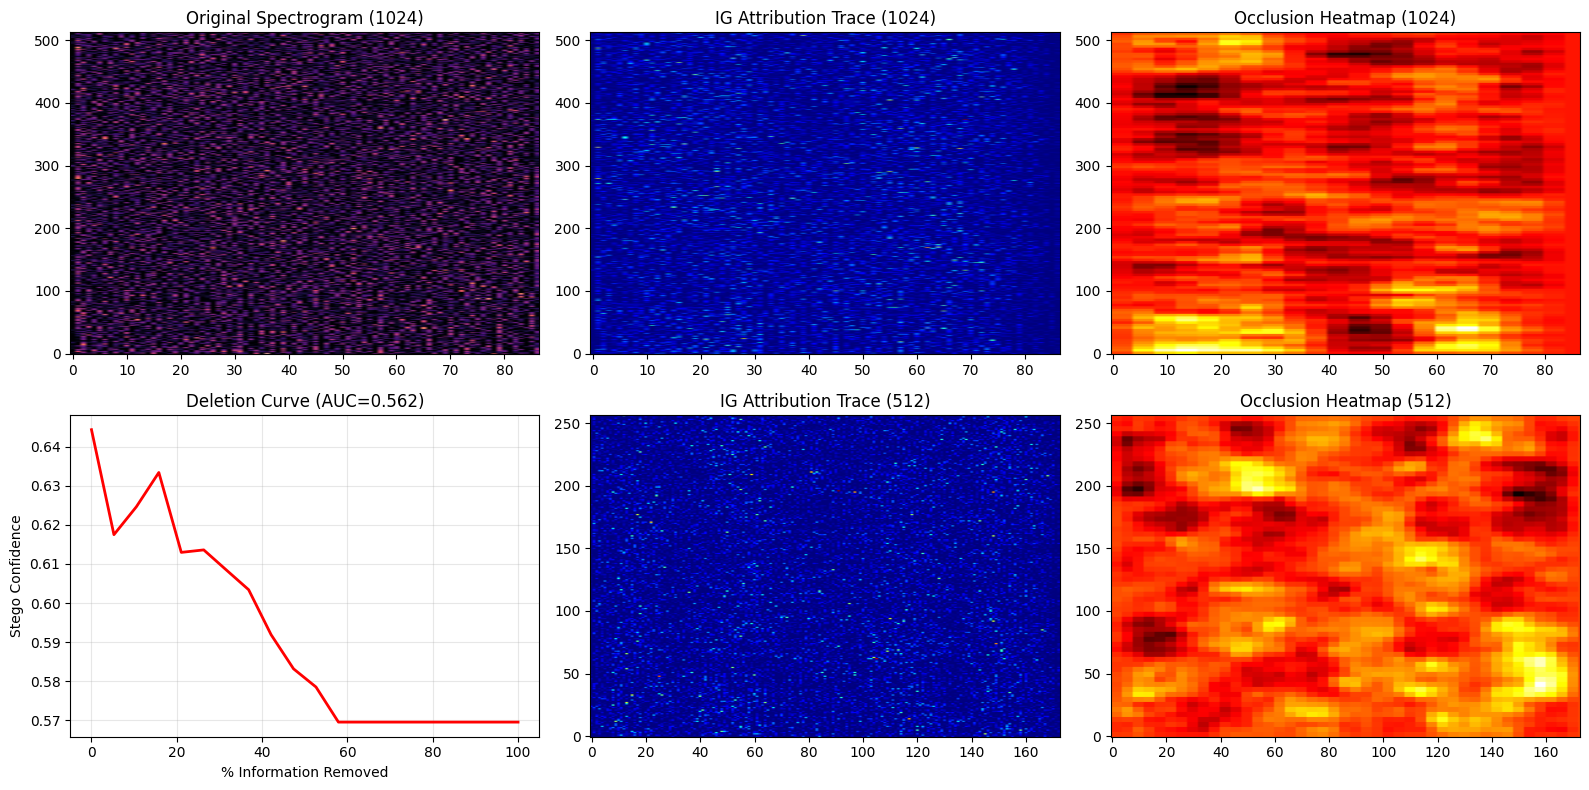

In [46]:
plt.figure(figsize=(16, 8))

# Stream 1 (1024-FFT) Analysis
plt.subplot(2, 3, 1)
plt.title("Original Spectrogram (1024)")
plt.imshow(x1_sample.cpu().squeeze().numpy(), aspect='auto', origin='lower', cmap='magma')

plt.subplot(2, 3, 2)
plt.title("IG Attribution Trace (1024)")
plt.imshow(ig1.cpu().squeeze().abs().numpy(), aspect='auto', origin='lower', cmap='jet')

plt.subplot(2, 3, 3)
plt.title("Occlusion Heatmap (1024)")
plt.imshow(occ1.cpu().squeeze().numpy(), aspect='auto', origin='lower', cmap='hot')

# Reliability and Secondary Stream
plt.subplot(2, 3, 4)
plt.title(f"Deletion Curve (AUC={auc:.3f})")
plt.plot(np.linspace(0, 100, len(scores)), scores, color='red', lw=2)
plt.xlabel("% Information Removed")
plt.ylabel("Stego Confidence")
plt.grid(alpha=0.3)

plt.subplot(2, 3, 5)
plt.title("IG Attribution Trace (512)")
plt.imshow(ig2.cpu().squeeze().abs().numpy(), aspect='auto', origin='lower', cmap='jet')

plt.subplot(2, 3, 6)
plt.title("Occlusion Heatmap (512)")
plt.imshow(occ2.cpu().squeeze().numpy(), aspect='auto', origin='lower', cmap='hot')

plt.tight_layout()
plt.show()

# MODEL DEMONSTRATION

✅ Successfully loaded model from /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/backbone_model_v41/Auspex_Universal_v1_seed2026_best.pt

--- Forensic Report Summary ---
{
  "timestamp": "2026-02-11T23:13:58.094716",
  "verdict": "COVER",
  "confidence": "89.02%",
  "model_balance": {
    "alpha_1024_weight": 0.49009066820144653,
    "alpha_512_weight": 0.5099093317985535,
    "alpha_1024_scaling": 0.9990063309669495,
    "alpha_512_scaling": 1.0058943033218384
  },
  "forensic_evidence": [],
  "fingerprint": "b3362f908b46"
}


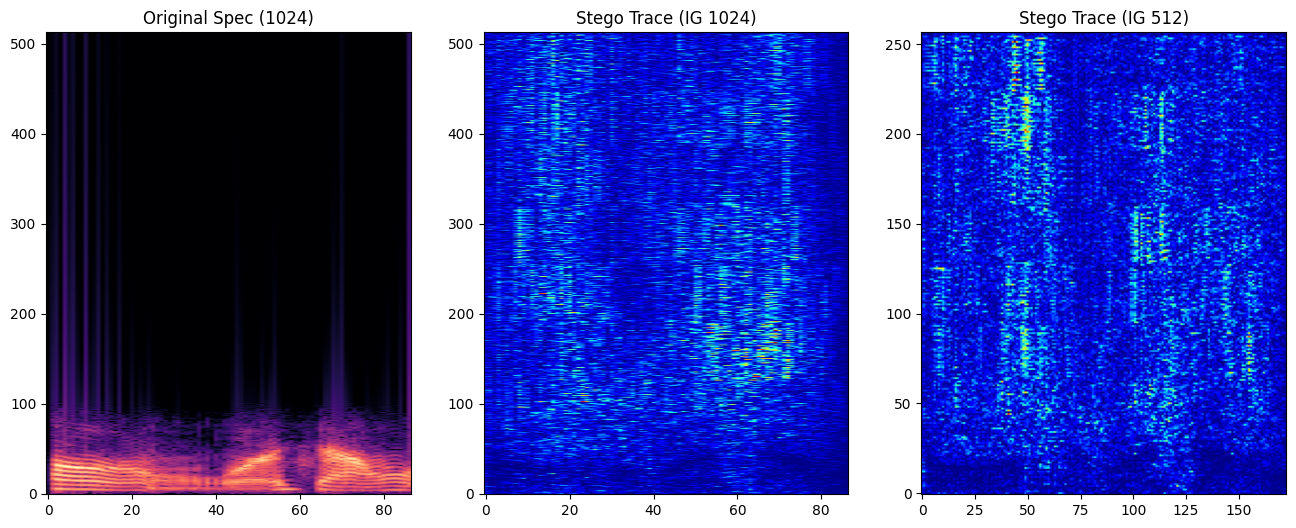

In [48]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
import subprocess
import tempfile
import json
import hashlib
import matplotlib.pyplot as plt
from datetime import datetime

# ==========================================
# 1. THE FORENSIC EXPLAINER CLASS
# ==========================================
class ForensicExplainer:
    def __init__(self, model, device):
        self.model = model.to(device).eval()
        self.device = device

    def get_stream_reliance(self):
        """Calculates global trust parameters based on the fusion layer."""
        with torch.no_grad():
            fw = self.model.fusion_weight.item()
            return {
                "alpha_1024_weight": fw,
                "alpha_512_weight": 1.0 - fw,
                "alpha_1024_scaling": self.model.alpha_1024.item(),
                "alpha_512_scaling": self.model.alpha_512.item()
            }

    def integrated_gradients(self, x1, x2, target=1, steps=50):
        """Path-based attribution to identify stego-sensitive spectral regions."""
        self.model.zero_grad()
        x1_base, x2_base = torch.zeros_like(x1).to(self.device), torch.zeros_like(x2).to(self.device)
        total_grad1, total_grad2 = torch.zeros_like(x1), torch.zeros_like(x2)

        for alpha in np.linspace(0, 1, steps):
            x1_s = (x1_base + alpha * (x1 - x1_base)).requires_grad_()
            x2_s = (x2_base + alpha * (x2 - x2_base)).requires_grad_()
            out = self.model(x1_s, x2_s)
            score = out[:, target].sum()
            score.backward()
            total_grad1 += x1_s.grad
            total_grad2 += x2_s.grad
            self.model.zero_grad()

        return (x1 - x1_base) * (total_grad1 / steps), (x2 - x2_base) * (total_grad2 / steps)

    def generate_forensic_report(self, att1, att2, pred, prob):
        """Automated diagnosis based on attribution density."""
        freq_bins = att1.shape[2]
        high_cut = int(freq_bins * 0.7)
        low_imp = att1[:, :, :int(freq_bins*0.3), :].abs().mean().item()
        high_imp = att1[:, :, high_cut:, :].abs().mean().item()

        evidence = []
        if high_imp > low_imp * 1.5:
            evidence.append({
                "type": "HF Anomaly",
                "severity": "CRITICAL",
                "desc": "High-frequency sensitivity detected, indicating stochastic embedding (LSB/PMS)."
            })

        reliance = self.get_stream_reliance()
        return {
            "timestamp": datetime.now().isoformat(),
            "verdict": "STEGO" if pred == 1 else "COVER",
            "confidence": f"{prob*100:.2f}%",
            "model_balance": reliance,
            "forensic_evidence": evidence,
            "fingerprint": hashlib.sha256(str(self.model.state_dict().keys()).encode()).hexdigest()[:12]
        }

# ==========================================
# 2. END-TO-END G.729A ANALYSIS PIPELINE
# ==========================================
def perform_forensic_analysis(g729_file_path, model, device):
    """
    Decodes G.729A, extracts dual-stream specs, performs inference,
    and generates XAI visualizations.
    """
    target_sr = 44100
    temp_dir = tempfile.mkdtemp()
    decoded_wav = os.path.join(temp_dir, "temp_decoded.wav")

    explainer = ForensicExplainer(model, device)

    try:
        # STEP 1: FFmpeg Decoding for G.729A
        cmd = ["ffmpeg", "-y", "-f", "g729", "-i", g729_file_path, "-ar", str(target_sr), "-ac", "1", decoded_wav]
        subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)

        # STEP 2: Forensic Preprocessing
        y, _ = librosa.load(decoded_wav, sr=target_sr)
        y = np.nan_to_num(y)
        y = np.clip(y, -1.0, 1.0)

        # STEP 3: Multi-Window Feature Extraction
        def get_spec(audio, n_fft, hop, target_f):
            spec = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop, window="hamming"))
            spec = librosa.amplitude_to_db(spec, ref=np.max)
            if spec.shape[1] < target_f:
                spec = np.pad(spec, ((0, 0), (0, target_f - spec.shape[1])))
            else:
                spec = spec[:, :target_f]
            return spec

        s1024_np = get_spec(y, 1024, 512, 87)
        s512_np = get_spec(y, 512, 256, 173)

        # STEP 4: Inference
        t1024 = torch.from_numpy(s1024_np).unsqueeze(0).unsqueeze(0).float().to(device)
        t512 = torch.from_numpy(s512_np).unsqueeze(0).unsqueeze(0).float().to(device)

        with torch.no_grad():
            logits = model(t1024, t512)
            probs = F.softmax(logits, dim=1)[0]
            pred = torch.argmax(probs).item()

        # STEP 5: Explanations (Intrinsic & Post-hoc)
        ig1, ig2 = explainer.integrated_gradients(t1024, t512)
        report = explainer.generate_forensic_report(ig1, ig2, pred, probs[pred].item())

        # STEP 6: Visualization
        print(f"\n--- Forensic Report Summary ---")
        print(json.dumps(report, indent=2))


        plt.figure(figsize=(16, 6))
        plt.subplot(1, 3, 1); plt.title("Original Spec (1024)")
        plt.imshow(s1024_np, aspect='auto', origin='lower', cmap='magma')

        plt.subplot(1, 3, 2); plt.title("Stego Trace (IG 1024)")
        plt.imshow(ig1.cpu().squeeze().abs().numpy(), aspect='auto', origin='lower', cmap='jet')

        plt.subplot(1, 3, 3); plt.title("Stego Trace (IG 512)")
        plt.imshow(ig2.cpu().squeeze().abs().numpy(), aspect='auto', origin='lower', cmap='jet')
        plt.show()

    finally:
        if os.path.exists(decoded_wav): os.remove(decoded_wav)
        os.rmdir(temp_dir)

# ==========================================
# 3. EXECUTION
# ==========================================
STATS_1024 = (1.0754, 1.3645)
STATS_512  = (0.4015, 0.5033)

# 2. Instantiate the model architecture
model = SFFNLite_Universal(stats_1024=STATS_1024, stats_512=STATS_512)

# 3. Path to best checkpoint
checkpoint_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/backbone_model_v41/Auspex_Universal_v1_seed2026_best.pt"

# 4. Load the weights
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()
    print(f" Successfully loaded model from {checkpoint_path}")
else:
    print(" Checkpoint not found. Please verify the path.")
perform_forensic_analysis("/content/Chinese1.g729a", model, "cuda")